# Persistence Landscapes for Time Series TDA

This notebook replicates the persistence landscape methodology of **funTDA** (Part A) applied to time series data from the **Tribolium beetle model** (Part B), implementing everything in Python.

## Workflow overview

| Step | Method | funTDA equivalent |
|------|--------|-------------------|
| 1. Simulate time series | Tribolium difference equations | — |
| 2. Normalise to [0, 1] | Per-series min-max | Geodesic distances (implicit) |
| 3. Takens embedding | m=2, τ=3 → 2D point cloud | Adjacency matrix → graph |
| 4. Persistent homology | Vietoris-Rips (ripser) | Flagser (giotto-tda) |
| 5. Persistence landscape | H1, first layer, 500 bins | `landscape(PH, dim=1, KK=1, tseq)` |

**Reference:** Pereira & de Mello (2015). *Persistent homology for time series and spatial data clustering.* Expert Systems with Applications.

In [1]:
# ===========================================================================
# 1. Imports
# ===========================================================================

import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser   # Vietoris-Rips PH (same Ripser algorithm as TDAstats in R)

# Reproducibility: matches funTDA.R's set.seed(123)
np.random.seed(123)

## 1. Parameters

In [2]:
# ===========================================================================
# 2. Fixed parameters
# ===========================================================================

# Beetle model parameters from Costantino et al. (1995).
# These match Example1Beetles.R exactly.
B      = 7.48    # larval recruits per adult per time unit (no cannibalism)
C_EA   = 0.009   # egg cannibalism rate by adults
C_PA   = 0.004   # pupal cannibalism rate by adults
C_EL   = 0.012   # egg cannibalism rate by larvae
U_L    = 0.267   # larval death probability per time unit

# Adult death rates for the two dynamical regimes
U_A_STABLE    = 0.73   # stable equilibrium (point attractor)
U_A_APERIODIC = 0.96   # aperiodic oscillations (complex attractor)

# Simulation settings
N_SIM = 200   # simulations per regime (matches R: i in 1:200)
T_SIM = 200   # time steps; series length = T_SIM + 1 = 201 points

# Takens embedding parameters (matches R: buildTakens(x, 2, 3))
EMBED_DIM = 2
EMBED_LAG = 3

# Landscape parameters (matches funTDA.R: landscape(PH, dim=1, KK=1, tseq))
LANDSCAPE_DIM    = 1    # H1 (1-cycles = loops) captures periodicity structure
LANDSCAPE_LAYERS = 1    # first landscape function only (KK=1 in funTDA.R)
N_BINS           = 500  # evaluation grid resolution (length.out=500 in funTDA.R)

## 2. Simulate Tribolium Beetle Time Series

In [3]:
# ===========================================================================
# 3. Simulation function
# ===========================================================================

def simulate_beetles(u_a, L0, P0, A0, T=T_SIM):
    """
    Simulate Tribolium flour beetle population dynamics.

    Implements the discrete-time difference equation system from
    Costantino et al. (1995), SS genetic strain.
    The model tracks three life stages in two-week intervals:
      - L_t: feeding larvae
      - P_t: non-feeding larvae + pupae + callow adults
      - A_t: mature adults

    Equations:
      L_{t+1} = b * A_t * exp(-c_el * L_t  - c_ea * A_t)
      P_{t+1} = L_t * (1 - u_l)
      A_{t+1} = P_t * exp(-c_pa * A_t) + A_t * (1 - u_a)

    Note: although the R code calls ode(..., method='iteration'), deSolve
    with method='iteration' simply iterates the map rather than solving a
    continuous ODE. This Python version implements the same discrete map.

    Parameters
    ----------
    u_a : float
        Adult death probability. 0.73 → stable; 0.96 → aperiodic.
    L0, P0, A0 : float
        Initial larva, pupa, adult counts.
    T : int
        Number of iterations. Produces T+1 observations.

    Returns
    -------
    np.ndarray, shape (T+1,)
        Adult population time series (variable A only, matching R's select(A)).
    """
    L = [float(L0)]
    P = [float(P0)]
    A = [float(A0)]

    for _ in range(T):
        # All three equations use current values before any update,
        # so we compute L_{t+1} first, then use L_t (= L[-2] after appending)
        # for P_{t+1}, and P_t (= P[-2]) for A_{t+1}.
        L.append(B * A[-1] * np.exp(-C_EL * L[-1] - C_EA * A[-1]))
        P.append(L[-2] * (1 - U_L))                              # L[-2] = L_t
        A.append(P[-2] * np.exp(-C_PA * A[-1]) + A[-1] * (1 - u_a))  # P[-2] = P_t

    return np.array(A)  # length T+1 = 201

In [4]:
# ===========================================================================
# 4. Generate 200 stable + 200 aperiodic time series
# ===========================================================================

# Initial conditions L0, P0, A0 sampled from discrete uniform U[2, 100]
# (matches R: sample(2:100, 1) for each variable)

stable_series    = []
aperiodic_series = []

for _ in range(N_SIM):
    L0, P0, A0 = np.random.randint(2, 101, size=3)  # U[2, 100] inclusive
    stable_series.append(simulate_beetles(U_A_STABLE, L0, P0, A0))

for _ in range(N_SIM):
    L0, P0, A0 = np.random.randint(2, 101, size=3)
    aperiodic_series.append(simulate_beetles(U_A_APERIODIC, L0, P0, A0))

stable_series    = np.array(stable_series)    # shape (200, 201)
aperiodic_series = np.array(aperiodic_series) # shape (200, 201)

print(f"Stable series:    {stable_series.shape}")
print(f"Aperiodic series: {aperiodic_series.shape}")
print(f"Stable adult range:    [{stable_series.min():.2f}, {stable_series.max():.2f}]")
print(f"Aperiodic adult range: [{aperiodic_series.min():.2f}, {aperiodic_series.max():.2f}]")

Stable series:    (200, 201)
Aperiodic series: (200, 201)
Stable adult range:    [2.00, 203.97]
Aperiodic adult range: [2.00, 209.36]


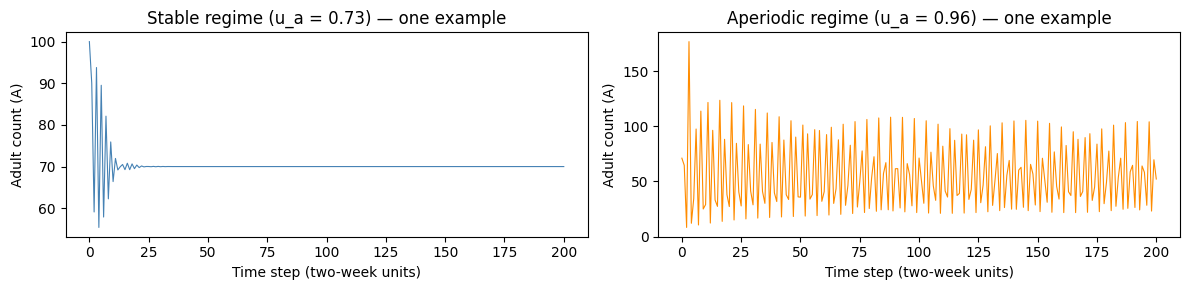

In [5]:
# Quick visualisation: one example per regime
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(stable_series[0], color='steelblue', linewidth=0.8)
axes[0].set_title("Stable regime (u_a = 0.73) — one example")
axes[0].set_xlabel("Time step (two-week units)")
axes[0].set_ylabel("Adult count (A)")

axes[1].plot(aperiodic_series[0], color='darkorange', linewidth=0.8)
axes[1].set_title("Aperiodic regime (u_a = 0.96) — one example")
axes[1].set_xlabel("Time step (two-week units)")
axes[1].set_ylabel("Adult count (A)")

plt.tight_layout()
plt.show()

## 3. Min-Max Normalisation to [0, 1]

In [6]:
# ===========================================================================
# 5. Per-series min-max normalisation
# ===========================================================================

# WHY: Raw adult counts depend on initial conditions and can range widely
# (e.g., 0 to 100+). Normalising each series independently to [0, 1] makes
# the Takens embedding scale-invariant, so the Vietoris-Rips filtration
# captures attractor shape (topology) rather than amplitude.
#
# This is analogous to funTDA.ipynb's GraphGeodesicDistance step, which
# implicitly normalises network distances so that PH values fall in [0, 1].
#
# Trade-off: per-series normalisation discards amplitude differences between
# individual runs, but preserves the topological structure of each attractor —
# which is exactly what we want to compare across regimes.

def normalize_01(series):
    """Min-max normalisation of a 1D array to the [0, 1] interval."""
    lo, hi = series.min(), series.max()
    if hi == lo:
        return np.zeros_like(series, dtype=float)  # constant series → all zeros
    return (series - lo) / (hi - lo)

stable_norm    = np.array([normalize_01(s) for s in stable_series])    # (200, 201)
aperiodic_norm = np.array([normalize_01(s) for s in aperiodic_series]) # (200, 201)

print(f"Stable normalised:    min={stable_norm.min():.3f}, max={stable_norm.max():.3f}")
print(f"Aperiodic normalised: min={aperiodic_norm.min():.3f}, max={aperiodic_norm.max():.3f}")

Stable normalised:    min=0.000, max=1.000
Aperiodic normalised: min=0.000, max=1.000


## 4. Takens Delay Embedding

In [7]:
# ===========================================================================
# 6. Takens delay embedding
# ===========================================================================

# Takens' theorem (1981) guarantees that, for generic time series, the
# delay-embedding map
#
#   x_n → (x_n, x_{n+τ}, ..., x_{n+(m-1)τ})
#
# reconstructs the topology of the underlying dynamical attractor.
# Periodic/aperiodic attractors produce point clouds with 1-cycles (loops)
# that are detectable by H1 persistent homology.
# A stable fixed-point attractor produces a compact cluster with no loops.
#
# Parameters m=2, τ=3 match Example1Beetles.R: buildTakens(x, 2, 3).
# For a series of length 201 with m=2 and τ=3:
#   number of points = 201 - (2-1)*3 = 198

def takens_embedding(series, m=EMBED_DIM, tau=EMBED_LAG):
    """
    Reconstruct phase-space attractor via Takens delay embedding.

    Parameters
    ----------
    series : np.ndarray, shape (T,)
    m   : int  — embedding dimension (default 2)
    tau : int  — time delay        (default 3)

    Returns
    -------
    np.ndarray, shape (T - (m-1)*tau, m)
    """
    n = len(series) - (m - 1) * tau
    return np.array([[series[i + j * tau] for j in range(m)] for i in range(n)])


# Build point clouds for all series
stable_embedded    = np.array([takens_embedding(s) for s in stable_norm])    # (200, 198, 2)
aperiodic_embedded = np.array([takens_embedding(s) for s in aperiodic_norm]) # (200, 198, 2)

print(f"Stable embedded:    {stable_embedded.shape}  (n_series, n_points, dim)")
print(f"Aperiodic embedded: {aperiodic_embedded.shape}")

Stable embedded:    (200, 198, 2)  (n_series, n_points, dim)
Aperiodic embedded: (200, 198, 2)


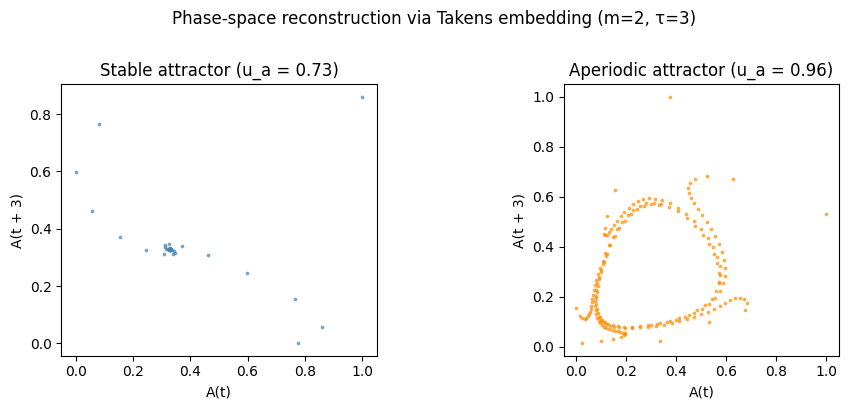

In [8]:
# Visualise phase-space attractors: one stable vs one aperiodic example
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(stable_embedded[0, :, 0], stable_embedded[0, :, 1],
                s=3, alpha=0.6, color='steelblue')
axes[0].set_title("Stable attractor (u_a = 0.73)")
axes[0].set_xlabel("A(t)"); axes[0].set_ylabel("A(t + 3)")
axes[0].set_aspect('equal')

axes[1].scatter(aperiodic_embedded[0, :, 0], aperiodic_embedded[0, :, 1],
                s=3, alpha=0.6, color='darkorange')
axes[1].set_title("Aperiodic attractor (u_a = 0.96)")
axes[1].set_xlabel("A(t)"); axes[1].set_ylabel("A(t + 3)")
axes[1].set_aspect('equal')

plt.suptitle("Phase-space reconstruction via Takens embedding (m=2, τ=3)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Persistent Homology

In [9]:
# ===========================================================================
# 7. Persistent homology via Vietoris-Rips filtration
# ===========================================================================

# We compute Vietoris-Rips PH using ripser (Bauer, 2021), which is the
# same underlying C++ library used by TDAstats in R (calculate_homology).
# Results are therefore numerically equivalent to the R code in Example1Beetles.R.
#
# - H0 (dimension 0): connected components — how many clusters of points exist
# - H1 (dimension 1): 1-cycles (loops) — detects closed orbits in the attractor
#
# ripser returns a dict with 'dgms': [h0_array, h1_array]
# Each array has shape (n_features, 2) with columns [birth, death].
# H0 always has one infinite-death feature (the last connected component);
# we filter these out when computing landscapes.

print("Computing persistent homology for all 400 series...")

# Store full ripser output (both H0 and H1) for each series
ph_stable    = [ripser(pts, maxdim=1)['dgms'] for pts in stable_embedded]
ph_aperiodic = [ripser(pts, maxdim=1)['dgms'] for pts in aperiodic_embedded]

print("Done.")

# Summarise H1 lifetime distributions
def max_h1_lifetime(dgms):
    """Return maximum H1 lifetime (birth-to-death) for one persistence diagram."""
    h1 = dgms[1]
    h1 = h1[h1[:, 1] < np.inf]   # drop infinite-death features
    if len(h1) == 0:
        return 0.0
    return (h1[:, 1] - h1[:, 0]).max()

stable_max_lt    = [max_h1_lifetime(d) for d in ph_stable]
aperiodic_max_lt = [max_h1_lifetime(d) for d in ph_aperiodic]

print(f"Stable    — mean max H1 lifetime: {np.mean(stable_max_lt):.5f}")
print(f"Aperiodic — mean max H1 lifetime: {np.mean(aperiodic_max_lt):.5f}")
print("(Stable series show near-zero H1 lifetimes: no loops in equilibrium attractor)")

Computing persistent homology for all 400 series...


Done.
Stable    — mean max H1 lifetime: 0.00346
Aperiodic — mean max H1 lifetime: 0.45556
(Stable series show near-zero H1 lifetimes: no loops in equilibrium attractor)


## 6. Persistence Landscapes

A **persistence landscape** (Bubenik, 2015) converts a persistence diagram into a sequence of functions $\lambda_k : \mathbb{R} \to \mathbb{R}$. The $k$-th landscape function is:

$$\lambda_k(t) = k\text{-th largest value of } \max\!\left(0,\; \min(t - b_i,\; d_i - t)\right)$$

where $(b_i, d_i)$ are the birth–death pairs. The $\max(0, \min(\cdot,\cdot))$ factor is the **tent function** centred at the midpoint $(b_i + d_i)/2$ with height $(d_i - b_i)/2$.

We compute $\lambda_1$ only (first layer, `KK=1` in funTDA.R), for H1 features only (`dimension=1`).

In [10]:
# ===========================================================================
# 8. Persistence landscape function (first layer)
# ===========================================================================

def persistence_landscape_k1(birth_death, tseq):
    """
    Compute the first persistence landscape (k=1) on a fixed evaluation grid.

    Equivalent to R's: landscape(PH, dimension=1, KK=1, tseq)
    from the TDA package (Fasy et al., 2021).

    Parameters
    ----------
    birth_death : np.ndarray, shape (n_features, 2)
        Birth-death pairs for a single homology dimension (infinite-death
        features already removed).
    tseq : np.ndarray, shape (n_bins,)
        Shared evaluation grid (same for all samples).

    Returns
    -------
    np.ndarray, shape (n_bins,)
        First landscape function values at each grid point.
    """
    if len(birth_death) == 0:
        # No H1 features: landscape is identically zero (e.g., stable series)
        return np.zeros(len(tseq))

    b = birth_death[:, 0]   # birth values, shape (n_features,)
    d = birth_death[:, 1]   # death values, shape (n_features,)

    # Vectorised tent function: shape (n_bins, n_features)
    # tent_i(t) = max(0, min(t - b_i, d_i - t))
    tents = np.maximum(
        0,
        np.minimum(
            tseq[:, None] - b[None, :],   # t - birth  (n_bins x n_features)
            d[None, :] - tseq[:, None]    # death - t
        )
    )

    # k=1: the first landscape is the pointwise maximum over all tent functions
    return tents.max(axis=1)   # shape (n_bins,)


def extract_finite_h1(dgms):
    """
    Extract finite H1 birth-death pairs from a ripser output.
    Drops any pair where death == inf (which would occur if the whole
    point cloud is one connected component — rare for H1 but handled).
    """
    h1 = dgms[1]                     # ripser H1 array, shape (n_pairs, 2)
    return h1[h1[:, 1] < np.inf]     # remove infinite-death features

In [11]:
# ===========================================================================
# 9. Define shared evaluation grid (data-adaptive, 500 points)
# ===========================================================================

# The grid must be shared across all 400 series so that landscapes live in
# the same functional space and can be compared (mean, variance, FDA tests).
#
# Grid range: [global_min_birth, global_max_death] across all H1 features.
# This is the data-adaptive analogue of funTDA.R's fixed tseq = seq(0, 1, 500),
# which worked because geodesic distances happen to fall in [0, 1].
# Here we adapt to the actual Rips filtration scale after normalisation.

all_h1_pairs = np.concatenate(
    [extract_finite_h1(d) for d in ph_stable + ph_aperiodic]
)

t_global_min = all_h1_pairs[:, 0].min()
t_global_max = all_h1_pairs[:, 1].max()

tseq = np.linspace(t_global_min, t_global_max, N_BINS)

print(f"H1 birth range: [{all_h1_pairs[:, 0].min():.5f}, {all_h1_pairs[:, 0].max():.5f}]")
print(f"H1 death range: [{all_h1_pairs[:, 1].min():.5f}, {all_h1_pairs[:, 1].max():.5f}]")
print(f"Evaluation grid: {N_BINS} points on [{t_global_min:.5f}, {t_global_max:.5f}]")

H1 birth range: [0.00000, 0.59928]
H1 death range: [0.00000, 0.76823]
Evaluation grid: 500 points on [0.00000, 0.76823]


In [12]:
# ===========================================================================
# 10. Compute persistence landscapes for all 400 series
# ===========================================================================

# Each row i is the first H1 landscape function for series i,
# evaluated at the 500 shared grid points.
# This mirrors the matrix format in funTDA.R:
#   DataSymp  (9 subjects × 500 values)
#   DataAsymp (8 subjects × 500 values)

stable_landscapes = np.array(
    [persistence_landscape_k1(extract_finite_h1(d), tseq) for d in ph_stable]
)  # shape (200, 500)

aperiodic_landscapes = np.array(
    [persistence_landscape_k1(extract_finite_h1(d), tseq) for d in ph_aperiodic]
)  # shape (200, 500)

print(f"Stable landscapes matrix:    {stable_landscapes.shape}  (n_series × n_bins)")
print(f"Aperiodic landscapes matrix: {aperiodic_landscapes.shape}")
print(f"\nMean maximum landscape value:")
print(f"  Stable:    {stable_landscapes.max(axis=1).mean():.5f}  (near zero → no loops)")
print(f"  Aperiodic: {aperiodic_landscapes.max(axis=1).mean():.5f}  (prominent → loops present)")

Stable landscapes matrix:    (200, 500)  (n_series × n_bins)
Aperiodic landscapes matrix: (200, 500)

Mean maximum landscape value:
  Stable:    0.00158  (near zero → no loops)
  Aperiodic: 0.22740  (prominent → loops present)


## 7. Visualisation

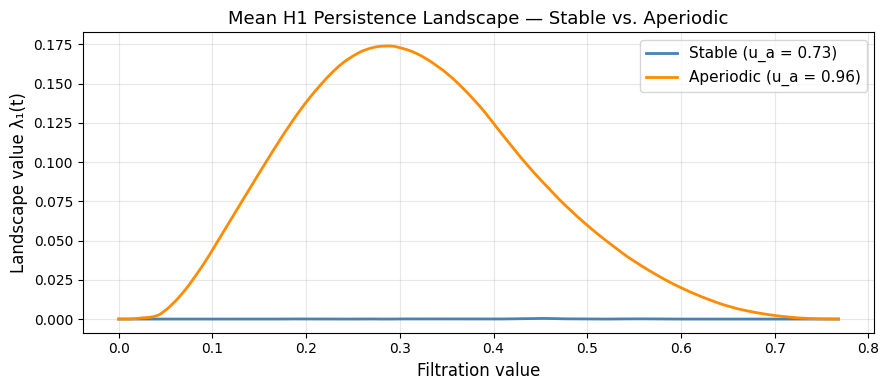

In [13]:
# ===========================================================================
# 11. Mean landscape comparison
# ===========================================================================

# This plot is the Python equivalent of funTDA.R's:
#   plot(mean.fd(fdSymp),  main='Mean Symptomatic Landscape')
#   plot(mean.fd(fdAsymp), main='Mean Asymptomatic Landscape')

mean_stable    = stable_landscapes.mean(axis=0)
mean_aperiodic = aperiodic_landscapes.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(tseq, mean_stable,    color='steelblue',  linewidth=2, label='Stable (u_a = 0.73)')
ax.plot(tseq, mean_aperiodic, color='darkorange', linewidth=2, label='Aperiodic (u_a = 0.96)')

ax.set_xlabel("Filtration value", fontsize=12)
ax.set_ylabel("Landscape value λ₁(t)", fontsize=12)
ax.set_title("Mean H1 Persistence Landscape — Stable vs. Aperiodic", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mean_landscapes.png", dpi=150, bbox_inches='tight')
plt.show()

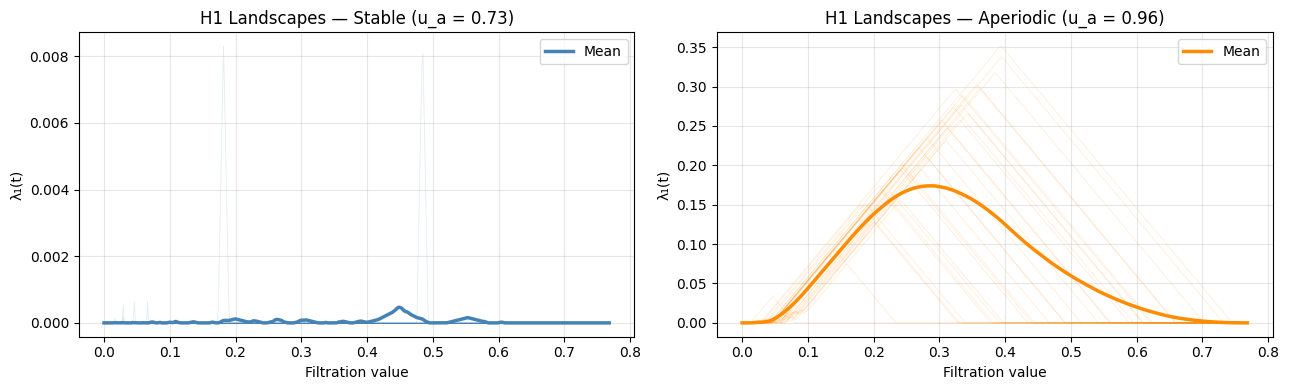

In [14]:
# ===========================================================================
# 12. Individual landscapes + mean overlay (sample of 30 per group)
# ===========================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i in range(min(30, N_SIM)):
    axes[0].plot(tseq, stable_landscapes[i],    color='steelblue',  alpha=0.15, linewidth=0.6)
    axes[1].plot(tseq, aperiodic_landscapes[i], color='darkorange', alpha=0.15, linewidth=0.6)

axes[0].plot(tseq, mean_stable,    color='steelblue',  linewidth=2.5, label='Mean')
axes[1].plot(tseq, mean_aperiodic, color='darkorange', linewidth=2.5, label='Mean')

for ax, title in zip(axes, ["Stable (u_a = 0.73)", "Aperiodic (u_a = 0.96)"]):
    ax.set_title(f"H1 Landscapes — {title}", fontsize=12)
    ax.set_xlabel("Filtration value")
    ax.set_ylabel("λ₁(t)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("individual_landscapes.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Outputs

Saved arrays can be loaded in future sessions for FPCA and permutation testing (next steps, following `funTDA.R`).

In [15]:
# ===========================================================================
# 13. Save landscape matrices and shared grid
# ===========================================================================

# Format: rows = time series, columns = grid evaluation points.
# Mirrors funTDA.R's DataSymp (9×500) and DataAsymp (8×500) matrices.

np.save("stable_landscapes.npy",    stable_landscapes)     # shape (200, 500)
np.save("aperiodic_landscapes.npy", aperiodic_landscapes)  # shape (200, 500)
np.save("tseq.npy",                 tseq)                  # shape (500,)

print("Saved:")
print(f"  stable_landscapes.npy    — {stable_landscapes.shape}")
print(f"  aperiodic_landscapes.npy — {aperiodic_landscapes.shape}")
print(f"  tseq.npy                 — {tseq.shape}")
print("\nNext steps (to replicate funTDA.R analysis):")
print("  - Functional PCA on combined landscape matrix (200+200 × 500)")
print("  - Permutation hypothesis test for mean landscape equality")

Saved:
  stable_landscapes.npy    — (200, 500)
  aperiodic_landscapes.npy — (200, 500)
  tseq.npy                 — (500,)

Next steps (to replicate funTDA.R analysis):
  - Functional PCA on combined landscape matrix (200+200 × 500)
  - Permutation hypothesis test for mean landscape equality
